In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import the domain
from intervalinf.core.domain import IntervalDomain

# Import space
from intervalinf.spaces import Lebesgue

# Import Function
from intervalinf.core.functions import Function

# Import function providers
from intervalinf.providers import (
    SineFunctionProvider,
    CosineFunctionProvider,
    FourierFunctionProvider,
    HatFunctionProvider,
)

# Function and Basis Providers Demo

## Table of Contents

1. [Introduction to Providers](#1-introduction-to-providers)
2. [Indexed Function Providers](#2-indexed-function-providers)
3. [Comparing Different Provider Types](#3-comparing-different-provider-types)
4. [Verifying Orthonormality](#4-verifying-orthonormality)
5. [Using Providers with Spaces](#5-using-providers-with-spaces)
6. [Visualizing Space Basis via Provider](#6-visualizing-space-basis-via-provider)
7. [Custom Basis Functions](#7-custom-basis-functions)
8. [Hybrid Bases: Combining Function Types](#8-hybrid-bases-combining-function-types)
9. [Parametric Function Providers](#9-parametric-function-providers)
10. [Multi-Parameter Providers: Wavelets](#10-multi-parameter-providers-wavelets)
11. [Summary](#11-summary)

## 1. Introduction to Providers

### What Are Providers?

In `intervalinf`, **providers** are objects that generate families of functions systematically. Instead of creating each function individually, providers give you:

- **Indexed families**: Generate function `φ_i` for any index `i` (e.g., sine, cosine, Fourier, hat functions)
- **Parametric families**: Generate functions based on continuous parameters (e.g., Gaussians with varying centers)
- **Lazy evaluation**: Functions are created on-demand, not stored upfront
- **Infinite potential**: Can generate functions for any index, not limited by a pre-set dimension

### The Provider Hierarchy

**1. IndexedFunctionProvider**
   - Base class for indexed families: `φ_0, φ_1, φ_2, ...`
   - Method: `get_function_by_index(i)` returns the i-th function
   - Examples: `SineFunctionProvider`, `CosineFunctionProvider`, `FourierFunctionProvider`, `HatFunctionProvider`
   - Use when you have a systematic sequence of basis functions

**2. ParametricFunctionProvider**
   - Base class for parametric families: `f(x; θ)` where θ is a continuous parameter
   - Method: `get_function(theta=...)` returns function for given parameter value
   - Examples: Gaussian kernels with varying centers, radial basis functions
   - Use when parameters vary continuously, not discretely

**3. BasisProvider**
   - Wraps function providers for use with finite-dimensional spaces
   - Connects providers to Lebesgue/Sobolev spaces
   - Automatically created when you use `basis='fourier'` in space creation
   - Generally you work with IndexedFunctionProvider directly

### Why Use Providers?

1. **Systematic generation**: Define the pattern once, generate infinitely many functions
2. **Lazy evaluation**: Only create the functions you actually need
3. **Consistency**: All functions in a family share common properties
4. **Flexibility**: Work in infinite-dimensional spaces without pre-committing to a dimension
5. **Integration with spaces**: Providers can be attached to Lebesgue spaces for spectral methods

### Two Usage Modes

**Standalone Mode (Domain-Only)**:
```python
provider = SineFunctionProvider(domain)
phi_3 = provider.get_function_by_index(3)
# Functions are detached, can be used anywhere
```

**Attached Mode (With Space)**:
```python
space = Lebesgue(10, domain, basis='sine')
provider = space.basis_provider
phi_3 = space.get_basis_function(3)  # Uses provider internally
# Functions know they belong to the space
```

## 2. Indexed Function Providers

Indexed function providers generate systematic sequences of basis functions.

### Core API Usage:

In [2]:
# Create a domain
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')

# Create a provider (no dimension needed!)
sine_provider = SineFunctionProvider(domain)

# Get specific functions by index
phi_0 = sine_provider.get_function_by_index(0)
phi_3 = sine_provider.get_function_by_index(3)
phi_7 = sine_provider.get_function_by_index(7)

# Can generate functions for any index
phi_100 = sine_provider.get_function_by_index(100)  # Works!

### Detailed Example and Visualization:

Sine Function Provider:
  Domain: [0.0, 6.283185307179586]

Generated functions:
  φ_0: sin(1π(x-0.0)/6.283185307179586)
  φ_3: sin(4π(x-0.0)/6.283185307179586)
  φ_7: sin(8π(x-0.0)/6.283185307179586)


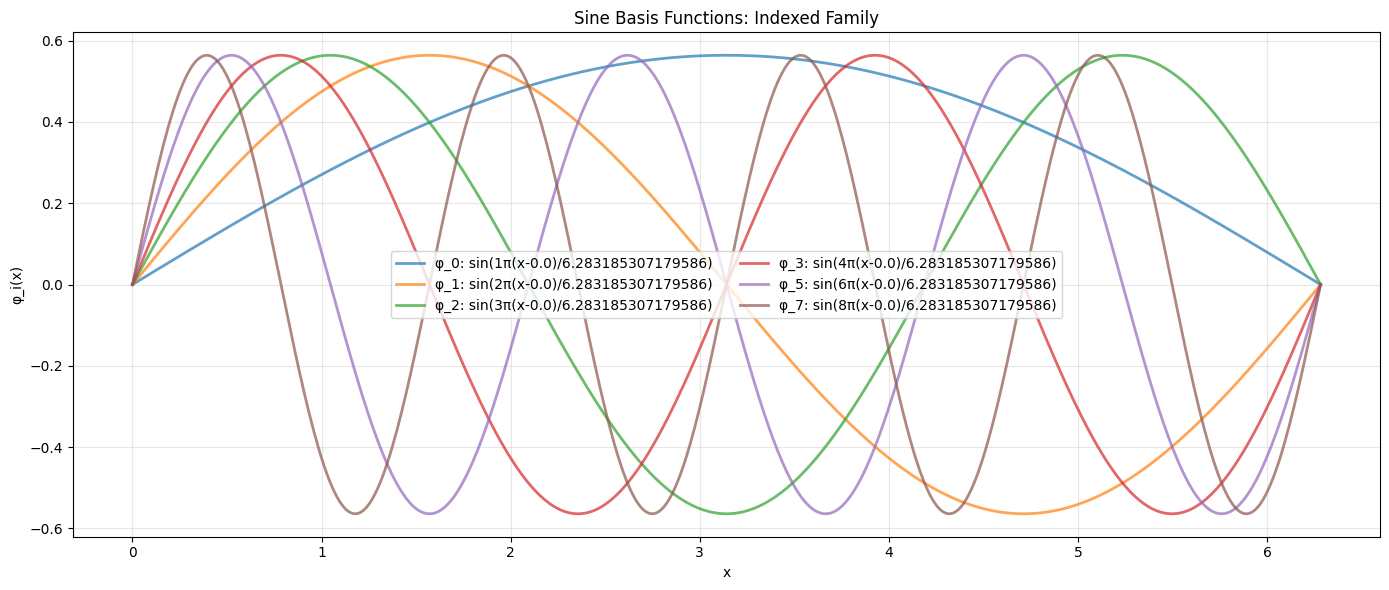


✓ Indexed families provide systematic access to basis functions
✓ Higher indices = higher frequency = finer details


In [3]:
# Create a domain
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')

# Create a sine function provider
sine_provider = SineFunctionProvider(domain)

print(f"Sine Function Provider:")
print(f"  Domain: {domain}")
print()

# Get specific basis functions by index
phi_0 = sine_provider.get_function_by_index(0)
phi_3 = sine_provider.get_function_by_index(3)
phi_7 = sine_provider.get_function_by_index(7)

print(f"Generated functions:")
print(f"  φ_0: {phi_0.name}")
print(f"  φ_3: {phi_3.name}")
print(f"  φ_7: {phi_7.name}")

# Visualize the family
x = np.linspace(0, 2*np.pi, 500)
plt.figure(figsize=(14, 6))

for i in [0, 1, 2, 3, 5, 7]:
    phi = sine_provider.get_function_by_index(i)
    plt.plot(x, phi(x), label=f'φ_{i}: {phi.name}', linewidth=2, alpha=0.7)

plt.xlabel('x')
plt.ylabel('φ_i(x)')
plt.title('Sine Basis Functions: Indexed Family')
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Indexed families provide systematic access to basis functions")
print("✓ Higher indices = higher frequency = finer details")

## 3. Comparing Different Provider Types

Different provider types generate different basis families, each suited to different boundary conditions and applications.

Basis Provider Comparison:
Provider        Description
Fourier         Global support, smooth, periodic
Sine            Global support, zero at boundaries
Cosine          Global support, derivative zero at boundaries
Hat             Local support, continuous, piecewise linear



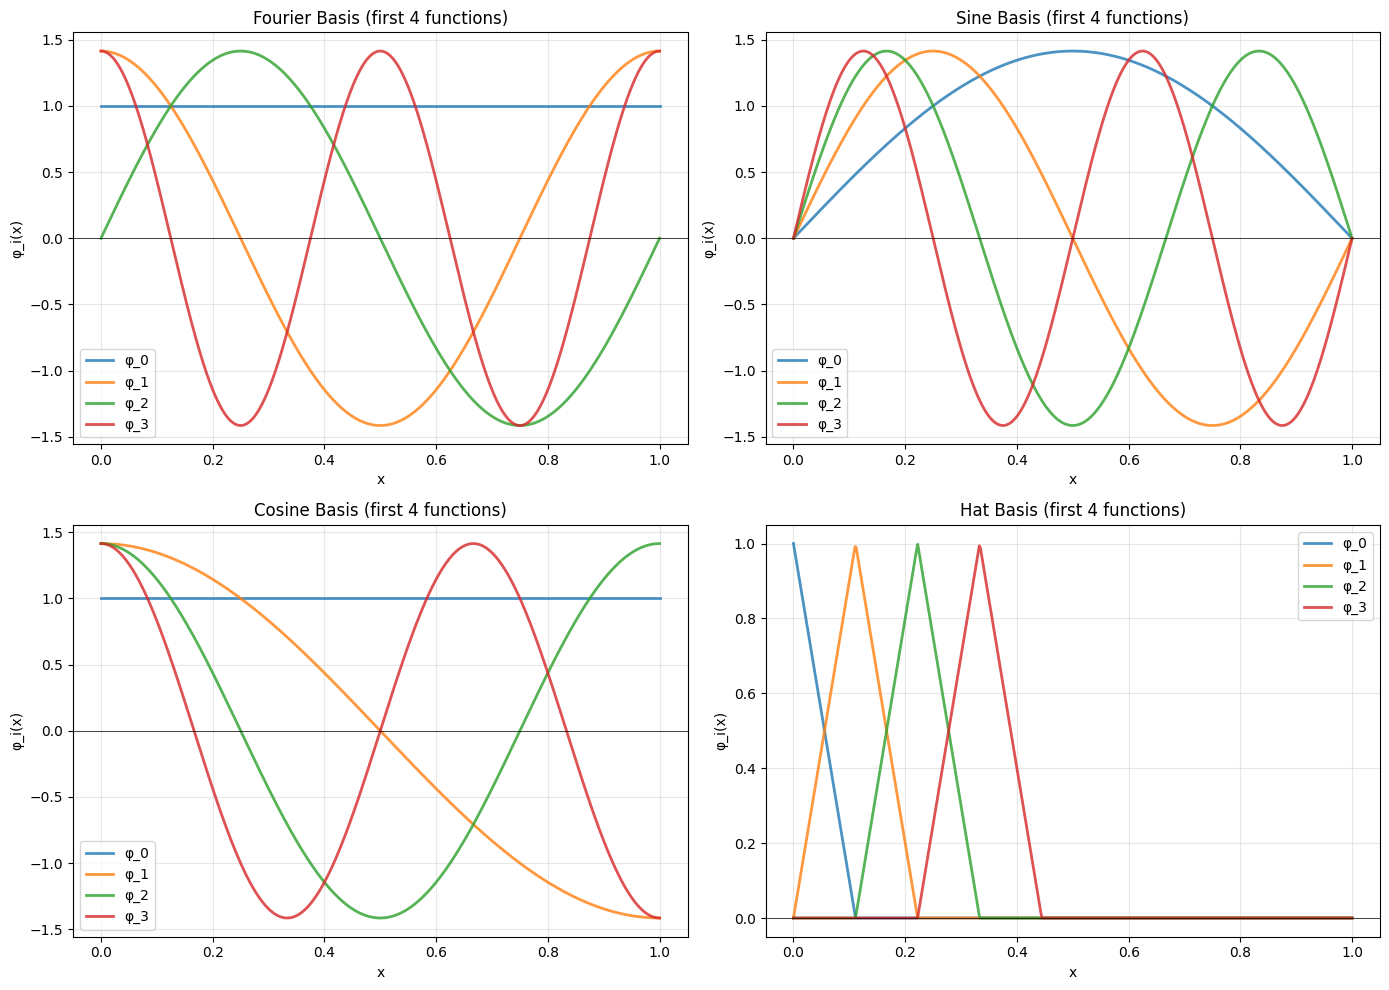


✓ Different basis types have different properties
✓ Fourier: global, smooth, best for periodic functions
✓ Hat: local, continuous, best for localized features
✓ Sine/Cosine: boundary conditions built-in


In [4]:
domain = IntervalDomain(0, 1, boundary_type='closed')

# Create different providers
providers = {
    'Fourier': FourierFunctionProvider(domain),
    'Sine': SineFunctionProvider(domain),
    'Cosine': CosineFunctionProvider(domain),
    'Hat': HatFunctionProvider(domain, n_nodes=10),
}

print("Basis Provider Comparison:")
print("=" * 80)
print(f"{'Provider':<15} {'Description'}")
print("=" * 80)

descriptions = {
    'Fourier': 'Global support, smooth, periodic',
    'Sine': 'Global support, zero at boundaries',
    'Cosine': 'Global support, derivative zero at boundaries',
    'Hat': 'Local support, continuous, piecewise linear',
}

for name, provider in providers.items():
    print(f"{name:<15} {descriptions[name]}")

print()

# Visualize first 4 basis functions from each provider
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x = np.linspace(0, 1, 500)

for idx, (name, provider) in enumerate(providers.items()):
    ax = axes[idx]

    # Plot first 4 basis functions
    for i in range(4):
        phi = provider.get_function_by_index(i)
        ax.plot(x, phi(x), label=f'φ_{i}', linewidth=2, alpha=0.8)

    ax.set_xlabel('x')
    ax.set_ylabel('φ_i(x)')
    ax.set_title(f'{name} Basis (first 4 functions)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n✓ Different basis types have different properties")
print("✓ Fourier: global, smooth, best for periodic functions")
print("✓ Hat: local, continuous, best for localized features")
print("✓ Sine/Cosine: boundary conditions built-in")

## 4. Verifying Orthonormality

Trigonometric bases (sine, cosine, Fourier) are orthonormal, which we can verify numerically.

Checking orthonormality of sine basis on [0, π]:

Gram Matrix G (should be identity if orthonormal):
[[ 1.00000000e+00 -5.55111512e-17  0.00000000e+00 -1.11022302e-16
   0.00000000e+00  1.38777878e-17]
 [-5.55111512e-17  1.00000000e+00  0.00000000e+00 -5.55111512e-17
  -1.38777878e-17 -2.08166817e-17]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
  -2.77555756e-17  5.55111512e-17]
 [-1.11022302e-16 -5.55111512e-17  0.00000000e+00  1.00000000e+00
   5.55111512e-17  0.00000000e+00]
 [ 0.00000000e+00 -1.38777878e-17 -2.77555756e-17  5.55111512e-17
   1.00000000e+00  0.00000000e+00]
 [ 1.38777878e-17 -2.08166817e-17  5.55111512e-17  0.00000000e+00
   0.00000000e+00  1.00000000e+00]]

Maximum deviation from identity: 2.22e-16


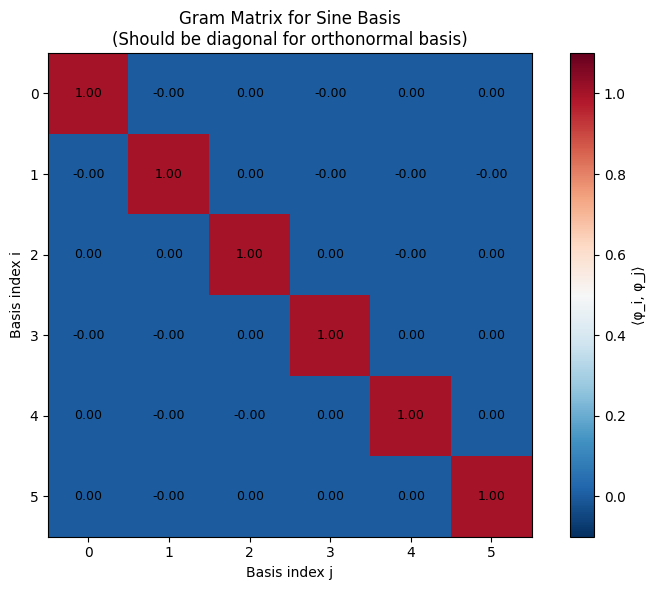


✓ Orthonormal bases have G = I (identity matrix)
✓ This makes coefficient computation trivial: c_i = ⟨f, φ_i⟩


In [5]:
# Check orthonormality numerically
domain = IntervalDomain(0, np.pi, boundary_type='closed')
provider = SineFunctionProvider(domain)

print(f"Checking orthonormality of sine basis on [0, π]:")
print()

# Compute Gram matrix G[i,j] = ⟨φ_i, φ_j⟩
n = 6
G = np.zeros((n, n))
x = np.linspace(0, np.pi, 1000)

basis_functions = [provider.get_function_by_index(i) for i in range(n)]

for i in range(n):
    for j in range(n):
        # Numerical integration for inner product
        integrand = basis_functions[i](x) * basis_functions[j](x)
        G[i, j] = np.trapz(integrand, x)

print("Gram Matrix G (should be identity if orthonormal):")
print(G)
print()

# Check how close to identity
identity_error = np.max(np.abs(G - np.eye(n)))
print(f"Maximum deviation from identity: {identity_error:.2e}")

# Visualize Gram matrix
plt.figure(figsize=(8, 6))
plt.imshow(G, cmap='RdBu_r', vmin=-0.1, vmax=1.1, interpolation='nearest')
plt.colorbar(label='⟨φ_i, φ_j⟩')
plt.xlabel('Basis index j')
plt.ylabel('Basis index i')
plt.title('Gram Matrix for Sine Basis\n(Should be diagonal for orthonormal basis)')

# Add text annotations
for i in range(n):
    for j in range(n):
        text = plt.text(j, i, f'{G[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Orthonormal bases have G = I (identity matrix)")
print("✓ This makes coefficient computation trivial: c_i = ⟨f, φ_i⟩")

## 5. Using Providers with Spaces

Providers integrate seamlessly with Lebesgue spaces. You can use string shortcuts or explicit providers.

### Core API Usage:

In [6]:
print("=" * 60)

# Method 1: Using string shortcuts
space_fourier = Lebesgue(10, domain, basis='fourier')
space_sine = Lebesgue(10, domain, basis='sine')

print("Via string shortcuts:")
print(f"  Fourier space: dim={space_fourier.dim}, basis type={space_fourier._basis_type}")
print(f"  Sine space: dim={space_sine.dim}, basis type={space_sine._basis_type}")
print()

# Method 2: Using explicit providers
cosine_provider = CosineFunctionProvider(domain)
space_cosine = Lebesgue(12, domain)
space_cosine.set_basis_provider(cosine_provider)

print("Via explicit provider:")
print(f"  Cosine space: dim={space_cosine.dim}")
print()

# Get basis functions from the space
phi_0 = space_fourier.get_basis_function(0)
phi_3 = space_fourier.get_basis_function(3)

print("Accessing basis functions through space:")
print(f"  φ_0: {phi_0.name}")
print(f"  φ_3: {phi_3.name}")
print()

# The space delegates to the provider
print("Under the hood:")
print(f"  Space has basis_provider: {hasattr(space_fourier, 'basis_provider')}")
print(f"  Provider type: {type(space_fourier.basis_provider).__name__}")

print("\n✓ String shortcuts create providers automatically")
print("✓ Explicit providers give you more control")
print("✓ The space delegates basis function generation to the provider")

Via string shortcuts:
  Fourier space: dim=10, basis type=fourier
  Sine space: dim=10, basis type=sine

Via explicit provider:
  Cosine space: dim=12

Accessing basis functions through space:
  φ_0: fourier_const
  φ_3: None

Under the hood:
  Space has basis_provider: True
  Provider type: CustomBasisProvider

✓ String shortcuts create providers automatically
✓ Explicit providers give you more control
✓ The space delegates basis function generation to the provider


In [7]:
# Method 1: String shortcut (easiest)
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')
space = Lebesgue(10, domain, basis='fourier')

# The space creates a provider internally
print(f"Space dimension: {space.dim}")
print(f"Provider type: {type(space.basis_provider).__name__}")

# Get basis functions through the space
phi_0 = space.get_basis_function(0)
phi_3 = space.get_basis_function(3)

Space dimension: 10
Provider type: CustomBasisProvider


## 6. Visualizing Space Basis via Provider

When you create a space with a basis, it internally uses a provider to generate basis functions.

Lebesgue space with Fourier basis:
  Dimension: 12
  Domain: [0.0, 6.283185307179586]

Underlying provider:
  Type: CustomBasisProvider



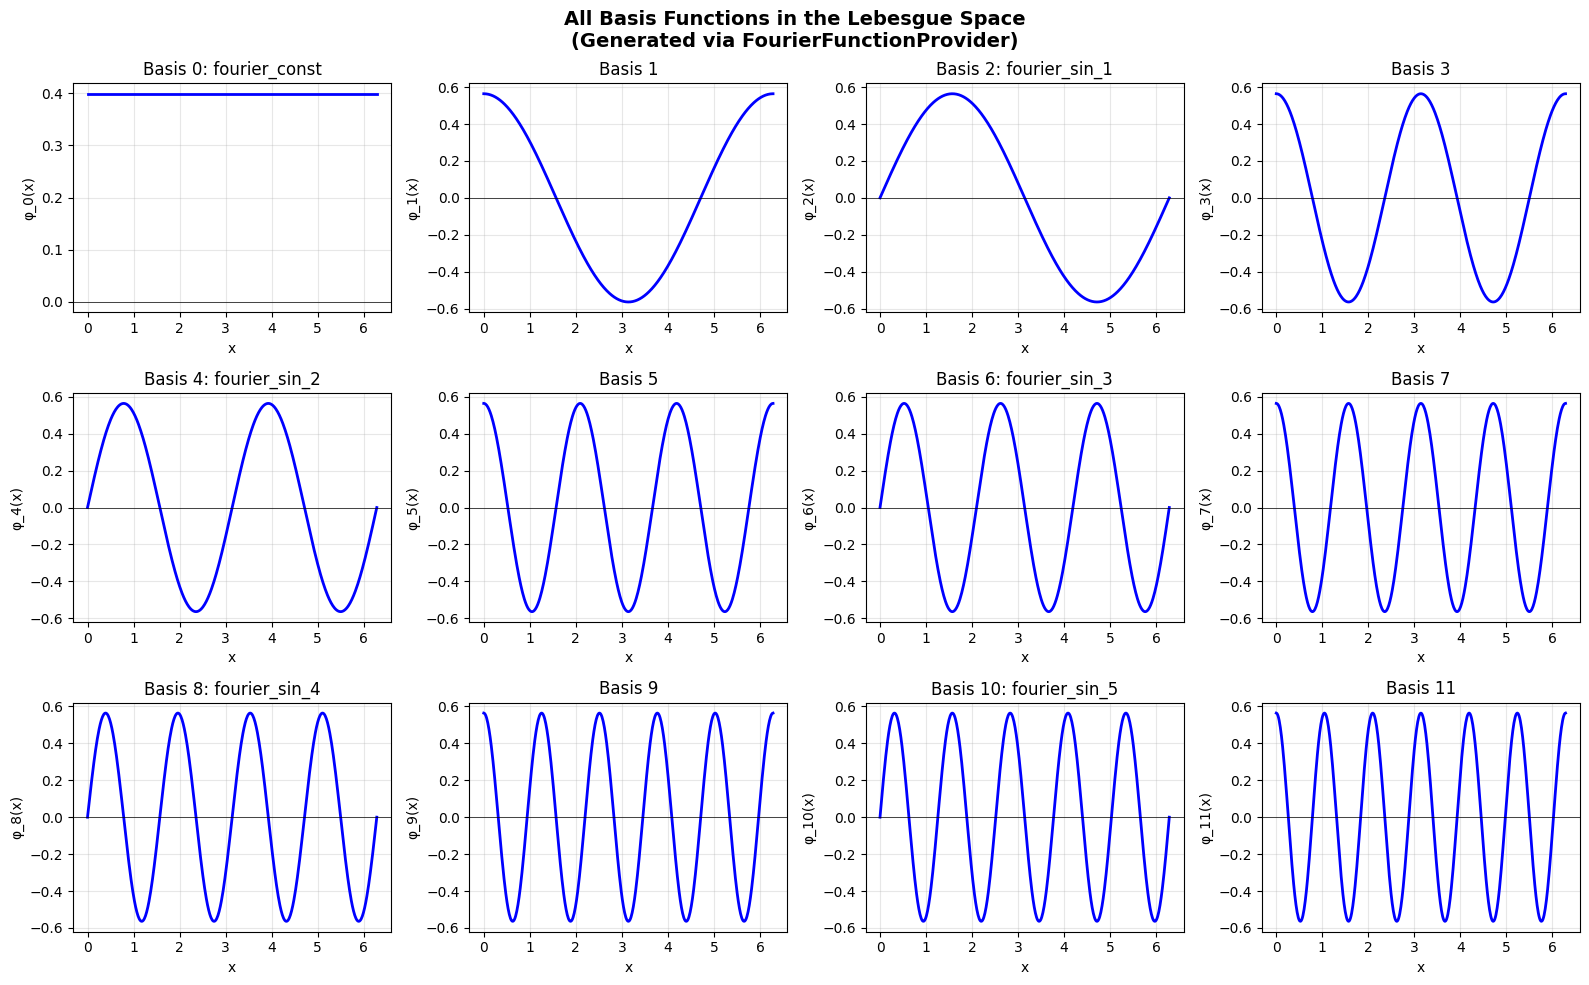


✓ The space's basis functions come from the provider
✓ Provider ensures consistency across all basis functions


In [8]:
# Create space with Fourier basis
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')
space = Lebesgue(12, domain, basis='fourier')

print(f"Lebesgue space with Fourier basis:")
print(f"  Dimension: {space.dim}")
print(f"  Domain: {space.function_domain}")
print()

# Access the underlying provider
provider = space.basis_provider
print(f"Underlying provider:")
print(f"  Type: {type(provider).__name__}")
print()

# Plot all basis functions
x = np.linspace(0, 2*np.pi, 500)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i in range(space.dim):
    # Get basis function from space (which uses provider internally)
    phi = space.get_basis_function(i)

    axes[i].plot(x, phi(x), 'b-', linewidth=2)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(f'φ_{i}(x)')
    axes[i].set_title(f'Basis {i}: {phi.name}' if phi.name else f'Basis {i}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(0, color='k', linewidth=0.5)

plt.suptitle('All Basis Functions in the Lebesgue Space\n(Generated via FourierFunctionProvider)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ The space's basis functions come from the provider")
print("✓ Provider ensures consistency across all basis functions")

## 7. Custom Basis Functions

You can create custom bases by passing lists of callables directly to Lebesgue spaces.

### Core API Usage:

Custom Polynomial Basis:
  Dimension: 6
  Basis type: direct_functions



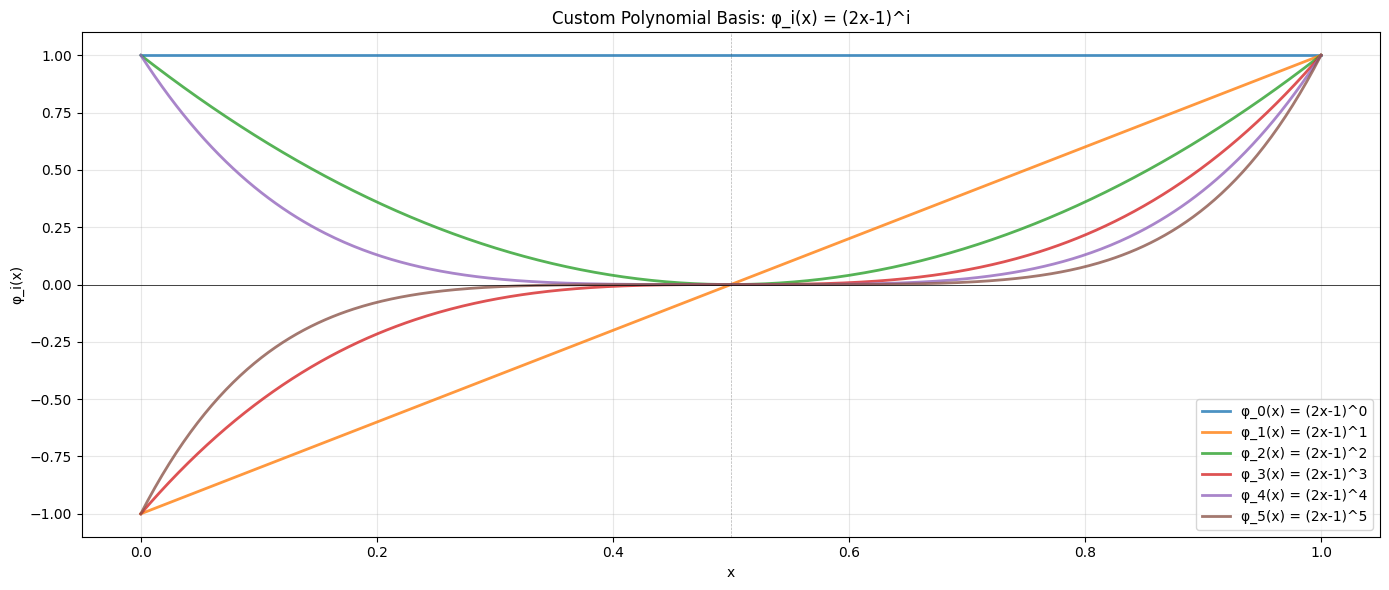


Gram matrix for custom basis:
[[1.00000000e+00 2.77555756e-17 3.33334001e-01 2.77555756e-17
  2.00001336e-01 0.00000000e+00]
 [2.77555756e-17 3.33334001e-01 2.77555756e-17 2.00001336e-01
  0.00000000e+00 1.42859147e-01]
 [3.33334001e-01 2.77555756e-17 2.00001336e-01 0.00000000e+00
  1.42859147e-01 0.00000000e+00]
 [2.77555756e-17 2.00001336e-01 0.00000000e+00 1.42859147e-01
  0.00000000e+00 1.11113783e-01]
 [2.00001336e-01 0.00000000e+00 1.42859147e-01 0.00000000e+00
  1.11113783e-01 0.00000000e+00]
 [0.00000000e+00 1.42859147e-01 0.00000000e+00 1.11113783e-01
  0.00000000e+00 9.09124309e-02]]



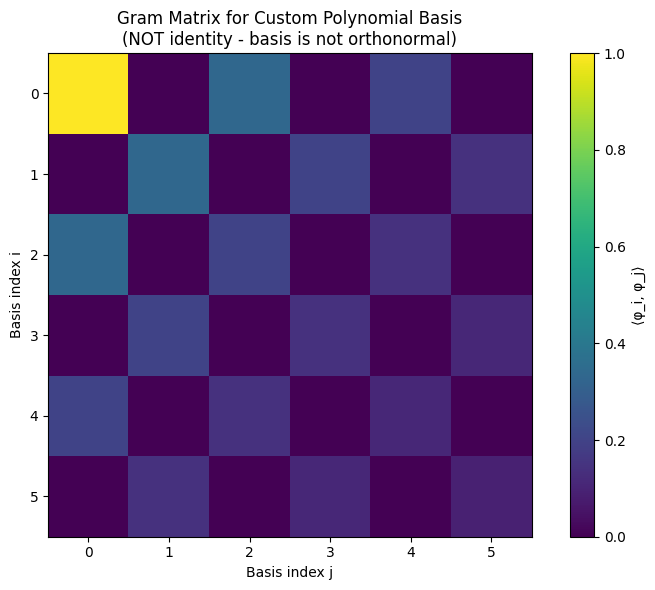


✓ Lebesgue spaces accept lists of callables as custom bases
✓ Non-orthonormal bases work, but require solving Gc=b for coefficients
✓ Custom bases integrate seamlessly with the Lebesgue space API


In [9]:
# Define custom basis functions
domain = IntervalDomain(0, 1, boundary_type='closed')

# Example: Shifted and scaled polynomials on [0, 1]
# φ_i(x) = (2x - 1)^i  (Legendre-like, but not normalized)
def make_polynomial(degree):
    def poly(x):
        return (2*x - 1)**degree
    return poly

# Create list of basis functions as callables
basis_callables = [make_polynomial(i) for i in range(6)]

# Create Lebesgue space with custom basis
# Pass the list of callables directly to the basis parameter
space_custom = Lebesgue(6, domain, basis=basis_callables)

print(f"Custom Polynomial Basis:")
print(f"  Dimension: {space_custom.dim}")
print(f"  Basis type: {space_custom._basis_type}")
print()

# Visualize custom basis
x = np.linspace(0, 1, 500)
plt.figure(figsize=(14, 6))

for i in range(6):
    phi = space_custom.get_basis_function(i)
    plt.plot(x, phi(x), label=f'φ_{i}(x) = (2x-1)^{i}', linewidth=2, alpha=0.8)

plt.xlabel('x')
plt.ylabel('φ_i(x)')
plt.title('Custom Polynomial Basis: φ_i(x) = (2x-1)^i')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0.5, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Check if actually orthonormal (they shouldn't be)
n = space_custom.dim
G = np.zeros((n, n))
x_quad = np.linspace(0, 1, 1000)

for i in range(n):
    for j in range(i, n):  # Symmetric, only compute upper triangle
        phi_i = space_custom.get_basis_function(i)
        phi_j = space_custom.get_basis_function(j)
        integrand = phi_i(x_quad) * phi_j(x_quad)
        G[i, j] = G[j, i] = np.trapz(integrand, x_quad)

print("\nGram matrix for custom basis:")
print(G)
print()

plt.figure(figsize=(8, 6))
plt.imshow(G, cmap='viridis', interpolation='nearest')
plt.colorbar(label='⟨φ_i, φ_j⟩')
plt.xlabel('Basis index j')
plt.ylabel('Basis index i')
plt.title('Gram Matrix for Custom Polynomial Basis\n(NOT identity - basis is not orthonormal)')
plt.tight_layout()
plt.show()

print("\n✓ Lebesgue spaces accept lists of callables as custom bases")
print("✓ Non-orthonormal bases work, but require solving Gc=b for coefficients")
print("✓ Custom bases integrate seamlessly with the Lebesgue space API")

In [10]:
# Define custom functions
def make_polynomial(degree):
    def poly(x):
        return (2*x - 1)**degree
    return poly

# Create list of basis callables
basis_callables = [make_polynomial(i) for i in range(6)]

# Pass directly to Lebesgue space
domain = IntervalDomain(0, 1, boundary_type='closed')
space = Lebesgue(6, domain, basis=basis_callables)

# Use like any other basis
phi_2 = space.get_basis_function(2)  # Gets (2x-1)^2

## 8. Hybrid Bases: Combining Function Types

Combine different function types (global + local) for optimal representation.

Hybrid Basis:
  Dimension: 6
  Components: 3 global + 3 local = 6 total



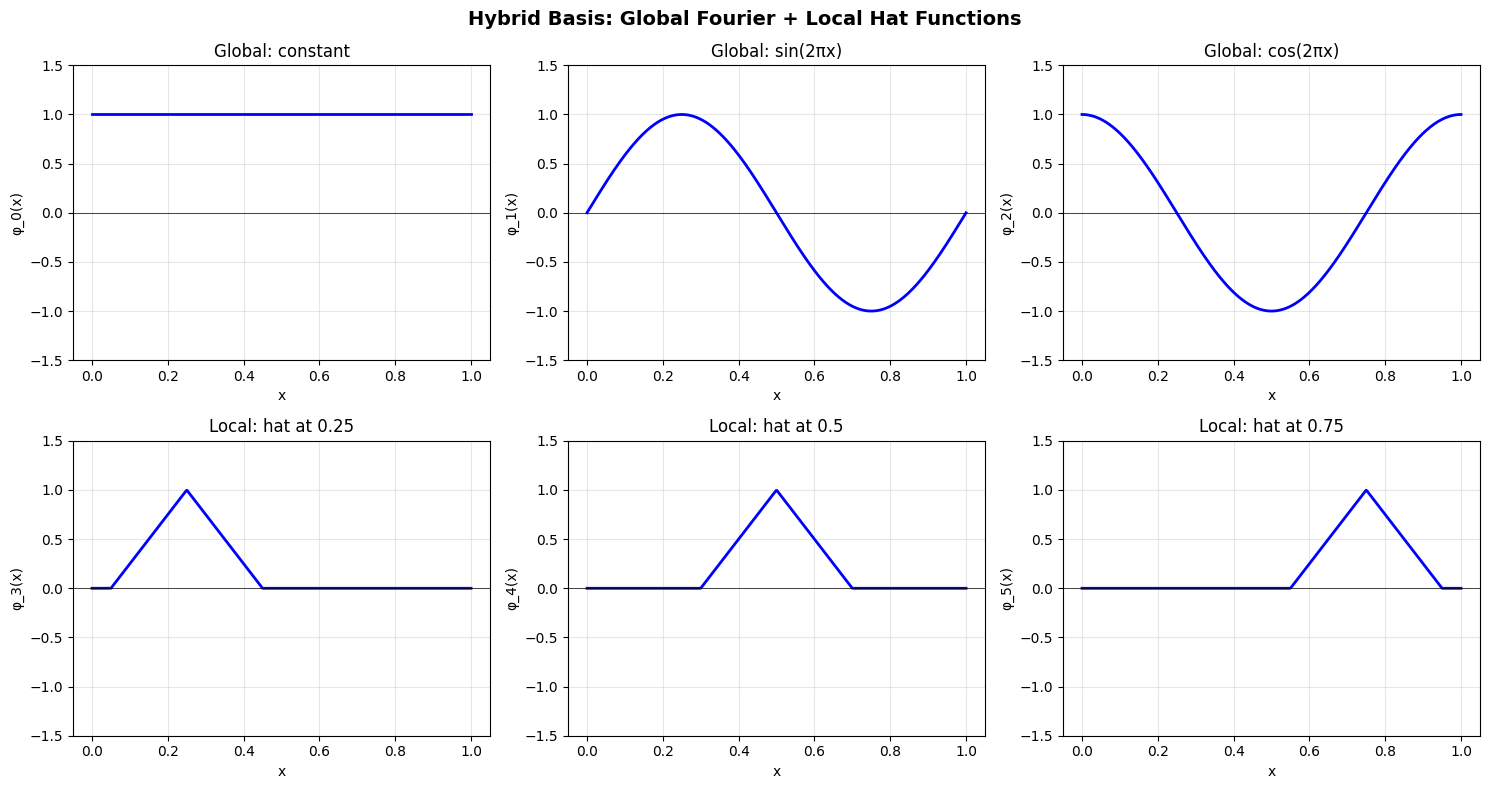


✓ Custom bases enable domain-specific basis design
✓ Can combine different function types for optimal representation
✓ Global functions capture trends, local functions capture details


In [11]:
# Create a hybrid basis: low-frequency global + high-frequency local
domain = IntervalDomain(0, 1, boundary_type='closed')

# Global part: First few Fourier modes
global_funcs = [
    lambda x: np.ones_like(x),  # Constant
    lambda x: np.sin(2*np.pi*x),  # One full oscillation
    lambda x: np.cos(2*np.pi*x),  # One full oscillation
]

# Local part: Hat functions for details
def make_hat(center, width=0.2):
    def hat(x):
        dist = np.abs(x - center)
        return np.maximum(0, 1 - dist/width)
    return hat

local_funcs = [make_hat(c) for c in [0.25, 0.5, 0.75]]

# Combine
hybrid_basis = global_funcs + local_funcs

# Create space with hybrid basis
space_hybrid = Lebesgue(len(hybrid_basis), domain, basis=hybrid_basis)

print(f"Hybrid Basis:")
print(f"  Dimension: {space_hybrid.dim}")
print(f"  Components: 3 global + 3 local = {space_hybrid.dim} total")
print()

# Visualize
x = np.linspace(0, 1, 500)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

labels = [
    'Global: constant',
    'Global: sin(2πx)',
    'Global: cos(2πx)',
    'Local: hat at 0.25',
    'Local: hat at 0.5',
    'Local: hat at 0.75',
]

for i in range(space_hybrid.dim):
    phi = space_hybrid.get_basis_function(i)
    axes[i].plot(x, phi(x), 'b-', linewidth=2)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(f'φ_{i}(x)')
    axes[i].set_title(labels[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(0, color='k', linewidth=0.5)
    axes[i].set_ylim([-1.5, 1.5])

plt.suptitle('Hybrid Basis: Global Fourier + Local Hat Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Custom bases enable domain-specific basis design")
print("✓ Can combine different function types for optimal representation")
print("✓ Global functions capture trends, local functions capture details")

## 9. Parametric Function Providers

Some providers accept continuous parameters rather than discrete indices.

### Core API Usage:

Gaussian Function Family:
  Domain: [-3.0, 3.0]
  Parameter: center μ ∈ [-3, 3]
  Fixed width: σ = 0.3



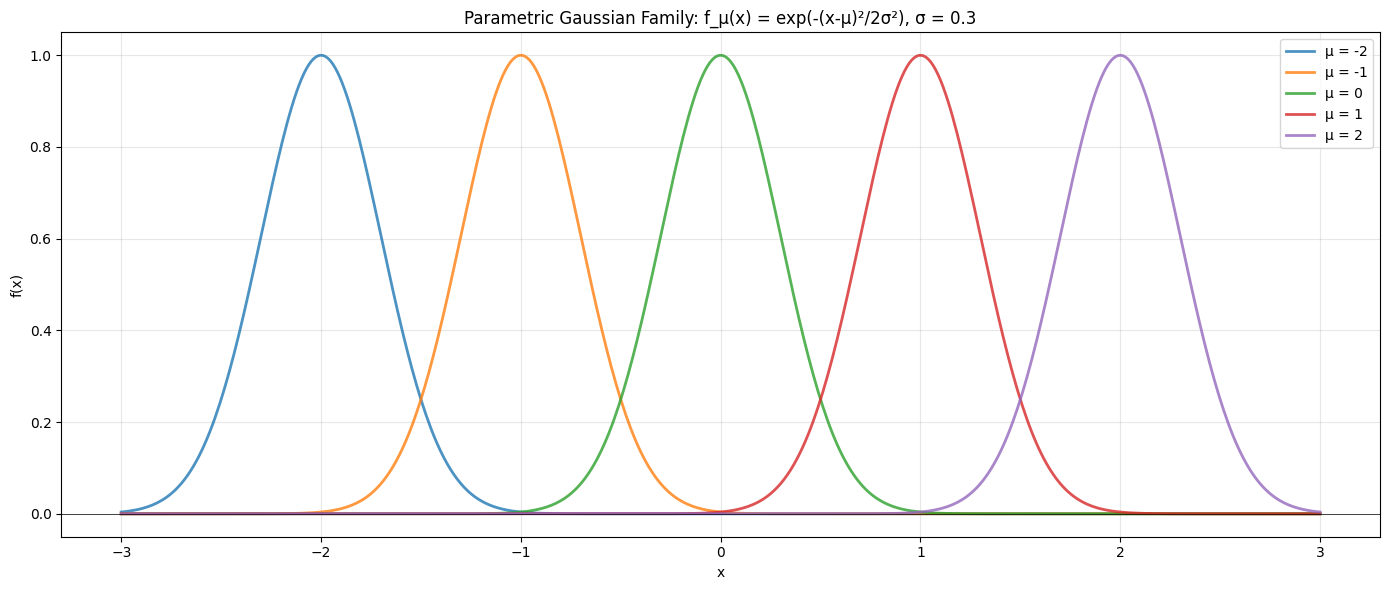


✓ Parametric families use continuous parameters, not indices
✓ Useful for kernel methods, radial basis functions, adaptive schemes
✓ Can be sampled at any parameter value


In [12]:
# Create a parametric Gaussian family
domain = IntervalDomain(-3, 3, boundary_type='closed')

class GaussianFamily:
    """Parametric family of Gaussian functions."""

    def __init__(self, domain, sigma=0.5):
        self.domain = domain
        self.sigma = sigma

    def get_function(self, center):
        """Get Gaussian centered at 'center'."""
        sigma = self.sigma
        def gaussian(x):
            return np.exp(-(x - center)**2 / (2 * sigma**2))

        return Function(
            self.domain,
            evaluate_callable=gaussian,
            name=f"Gaussian(μ={center:.1f}, σ={sigma})"
        )

# Create family
gaussian_family = GaussianFamily(domain, sigma=0.3)

print("Gaussian Function Family:")
print(f"  Domain: {domain}")
print(f"  Parameter: center μ ∈ [-3, 3]")
print(f"  Fixed width: σ = {gaussian_family.sigma}")
print()

# Generate functions at different centers
centers = [-2, -1, 0, 1, 2]
x = np.linspace(-3, 3, 500)

plt.figure(figsize=(14, 6))

for mu in centers:
    f = gaussian_family.get_function(mu)
    plt.plot(x, f(x), label=f'μ = {mu}', linewidth=2, alpha=0.8)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(f'Parametric Gaussian Family: f_μ(x) = exp(-(x-μ)²/2σ²), σ = {gaussian_family.sigma}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n✓ Parametric families use continuous parameters, not indices")
print("✓ Useful for kernel methods, radial basis functions, adaptive schemes")
print("✓ Can be sampled at any parameter value")

In [13]:
# Parametric providers use continuous parameters
# instead of discrete indices

# Example conceptual usage (implementation in detailed example below):
# provider = GaussianProvider(domain, sigma=0.3)
# g_at_neg1 = provider.get_function(center=-1.0)
# g_at_zero = provider.get_function(center=0.0)
# g_at_pos1 = provider.get_function(center=1.0)

print("Parametric providers generate functions with continuous parameters")
print("See detailed example below for implementation")

Parametric providers generate functions with continuous parameters
See detailed example below for implementation


## 10. Multi-Parameter Providers: Wavelets

Wavelets use multiple indices: scale (j) and translation (k).

Haar Wavelet Family:
  Two parameters: j (scale), k (translation)
  ψ_{j,k}(x) = 2^{j/2} ψ(2^j x - k)



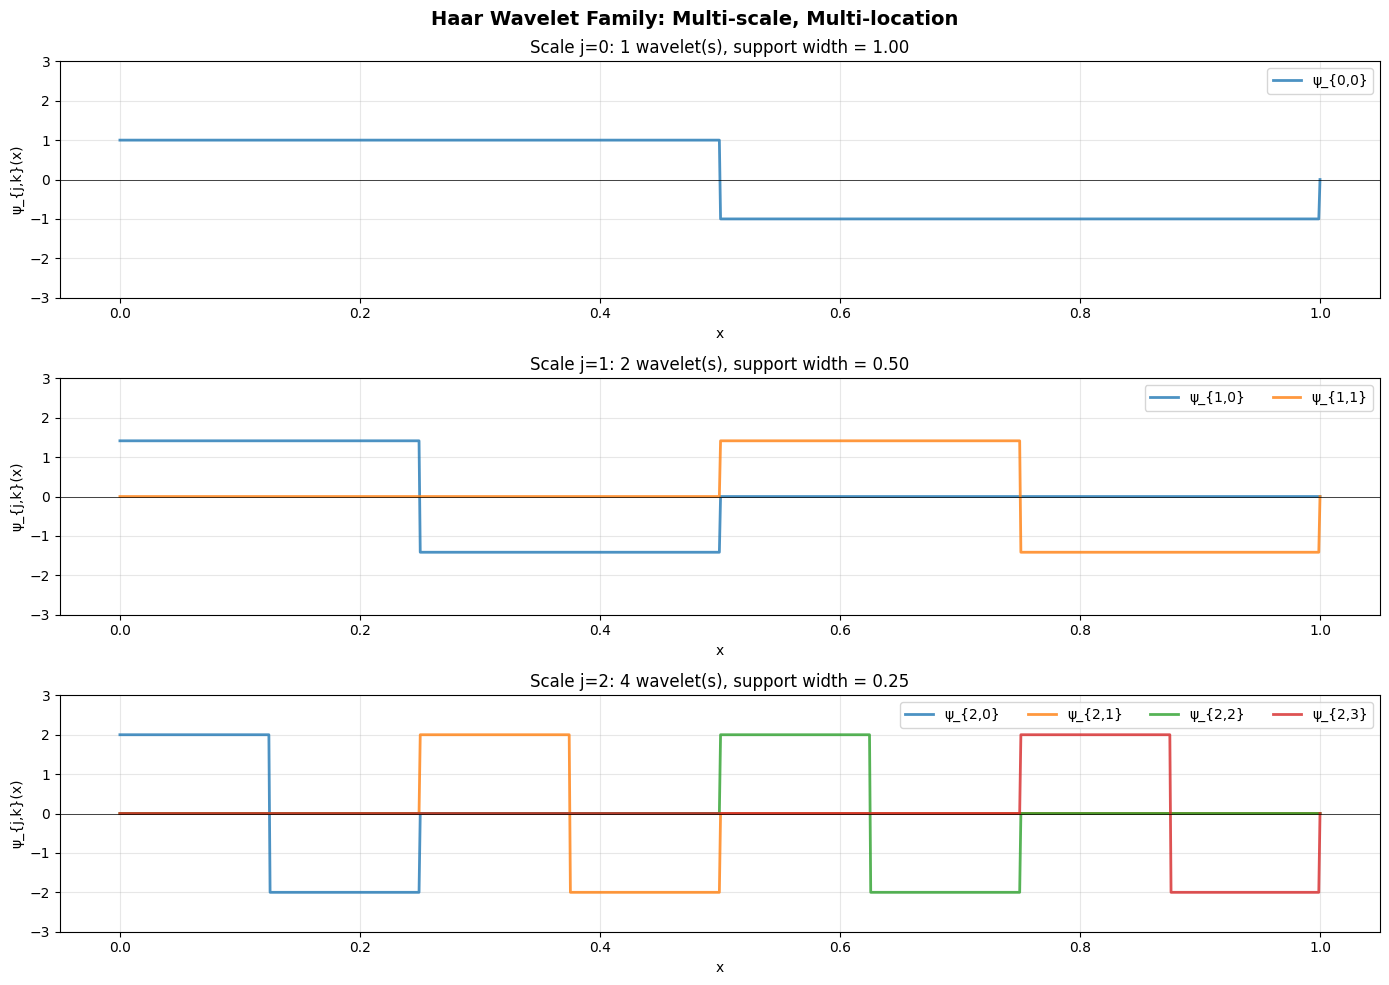


✓ Wavelets combine two indices: scale (j) and translation (k)
✓ Higher j = finer scale = narrower support = captures details
✓ At each scale, wavelets tile the domain with translations
✓ This multi-parameter structure is natural for providers


In [14]:
# Simple Haar wavelet example
# ψ_{j,k}(x) = 2^{j/2} ψ(2^j x - k)
# j = scale index (dyadic), k = translation index

domain = IntervalDomain(0, 1, boundary_type='closed')

def haar_mother(x):
    """Mother Haar wavelet."""
    result = np.zeros_like(x)
    mask1 = (x >= 0) & (x < 0.5)
    mask2 = (x >= 0.5) & (x < 1)
    result[mask1] = 1
    result[mask2] = -1
    return result

class HaarWaveletFamily:
    """Two-parameter wavelet family: (scale, translation)."""

    def __init__(self, domain):
        self.domain = domain

    def get_function(self, j, k):
        """Get wavelet at scale 2^j and translation k."""
        scale = 2**j

        def wavelet(x):
            # ψ_{j,k}(x) = 2^{j/2} ψ(2^j x - k)
            return np.sqrt(scale) * haar_mother(scale * x - k)

        return Function(
            self.domain,
            evaluate_callable=wavelet,
            name=f"Haar_{j},{k}"
        )

# Create family
haar_family = HaarWaveletFamily(domain)

print("Haar Wavelet Family:")
print("  Two parameters: j (scale), k (translation)")
print("  ψ_{j,k}(x) = 2^{j/2} ψ(2^j x - k)")
print()

# Generate wavelets at different scales and translations
wavelets_to_plot = [
    (0, 0),  # Coarsest scale
    (1, 0), (1, 1),  # Scale 2
    (2, 0), (2, 1), (2, 2), (2, 3),  # Scale 4
]

x = np.linspace(0, 1, 1000)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Group by scale
for scale_idx, j in enumerate([0, 1, 2]):
    ax = axes[scale_idx]

    # Plot all wavelets at this scale
    num_wavelets = 2**j
    for k in range(num_wavelets):
        psi = haar_family.get_function(j, k)
        ax.plot(x, psi(x), label=f'ψ_{{{j},{k}}}', linewidth=2, alpha=0.8)

    ax.set_xlabel('x')
    ax.set_ylabel('ψ_{j,k}(x)')
    ax.set_title(f'Scale j={j}: {num_wavelets} wavelet(s), support width = {1/num_wavelets:.2f}')
    ax.legend(ncol=num_wavelets)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_ylim([-3, 3])

plt.suptitle('Haar Wavelet Family: Multi-scale, Multi-location', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Wavelets combine two indices: scale (j) and translation (k)")
print("✓ Higher j = finer scale = narrower support = captures details")
print("✓ At each scale, wavelets tile the domain with translations")
print("✓ This multi-parameter structure is natural for providers")

## 11. Summary

### Key Takeaways

**1. Provider Types**
- **IndexedFunctionProvider**: Systematic sequences (sine, cosine, Fourier, hat functions)
- **ParametricFunctionProvider**: Continuous parameter families (Gaussians, RBFs)
- **Multi-parameter**: Wavelets with scale and translation

**2. Core Operations**
```python
# Create provider
provider = SineFunctionProvider(domain)

# Get functions by index
phi_i = provider.get_function_by_index(i)

# No dimension limit - generate any function on-demand
phi_1000 = provider.get_function_by_index(1000)
```

**3. Integration with Spaces**
```python
# String shortcut
space = Lebesgue(10, domain, basis='fourier')

# Explicit provider
provider = CosineFunctionProvider(domain)
space = Lebesgue(12, domain)
space.set_basis_provider(provider)

# Custom basis from callables
space = Lebesgue(5, domain, basis=[f1, f2, f3, f4, f5])
```

**4. Advantages**
- ✓ **Lazy evaluation**: Only create functions you need
- ✓ **Infinite potential**: Not limited by pre-set dimension
- ✓ **Consistency**: All functions in family share properties
- ✓ **Flexibility**: Mix and match different basis types

**5. Common Provider Types**

| Provider | Basis Functions | Boundary Conditions | Orthonormal |
|----------|----------------|---------------------|-------------|
| `SineFunctionProvider` | sin(kπx/L) | Dirichlet (zero at boundaries) | ✓ |
| `CosineFunctionProvider` | cos(kπx/L) | Neumann (zero derivative) | ✓ |
| `FourierFunctionProvider` | sin, cos pairs | Periodic | ✓ |
| `HatFunctionProvider` | Piecewise linear | Continuous | ✗ |
| Custom (list) | User-defined | User-defined | ✗ |

**6. When to Use Each Type**
- **Fourier**: Periodic problems, smooth functions, global representation
- **Sine**: Dirichlet boundary conditions, problems with fixed endpoints
- **Cosine**: Neumann boundary conditions, zero derivative at boundaries
- **Hat**: Finite element methods, local features, non-smooth functions
- **Custom**: Domain-specific requirements, hybrid representations

**7. Best Practices**
- Use providers when working with systematic function families
- Pass domain-only for standalone mode (maximum flexibility)
- Use with spaces for spectral/Galerkin methods
- Combine different providers for hybrid bases
- Remember: providers are lazy - functions created on-demand!

### Next Steps

Now that you understand providers, you can:
- Explore different basis types for your specific problem
- Create custom providers for domain-specific function families
- Use providers with spectral methods in Lebesgue/Sobolev spaces
- Combine multiple provider types for optimal representations